Device: cpu
Dataset shape: (3000, 32, 4) (3000, 32, 1)
Running: Linear
Running: MLP(h=32)
Running: LSTM(h=16,l=2)
Running: LSTM(h=8,l=1)
Running: LSTM(h=8,l=2)
Running: LSTM(h=8,l=3)
Running: LSTM(h=16,l=1)
Running: LSTM(h=16,l=2)
Running: LSTM(h=16,l=3)
Running: LSTM(h=32,l=1)
Running: LSTM(h=32,l=2)
Running: LSTM(h=32,l=3)

=== Leaderboard (Top 10) ===
         model  val_mse  val_mae   val_r2  test_mse  test_mae  test_r2  best_val_loss
LSTM(h=32,l=3) 0.000300 0.013713 0.993476  0.000292  0.013553 0.993610       0.000300
LSTM(h=32,l=2) 0.000333 0.014329 0.992766  0.000321  0.014021 0.992977       0.000333
LSTM(h=32,l=1) 0.000369 0.015036 0.991971  0.000362  0.014870 0.992099       0.000369
LSTM(h=16,l=2) 0.000426 0.015763 0.990733  0.000407  0.015416 0.991100       0.000426
LSTM(h=16,l=2) 0.000430 0.016529 0.990652  0.000417  0.016291 0.990889       0.000430
LSTM(h=16,l=3) 0.000630 0.019488 0.986301  0.000604  0.019060 0.986791       0.000630
LSTM(h=16,l=1) 0.000863 0.023443 0.981219

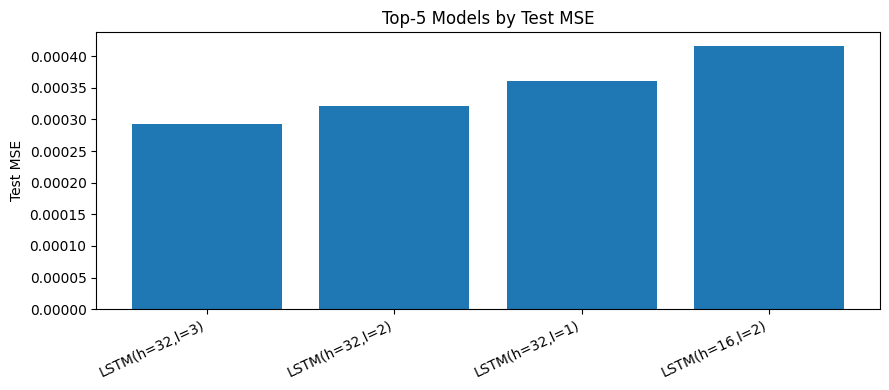

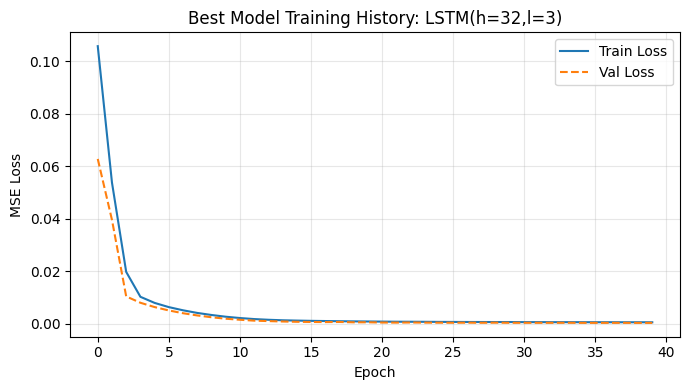

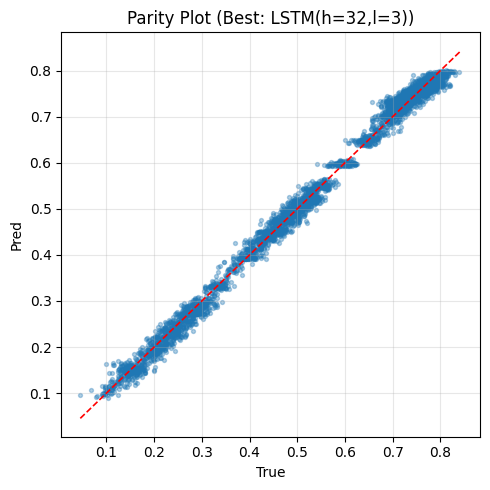

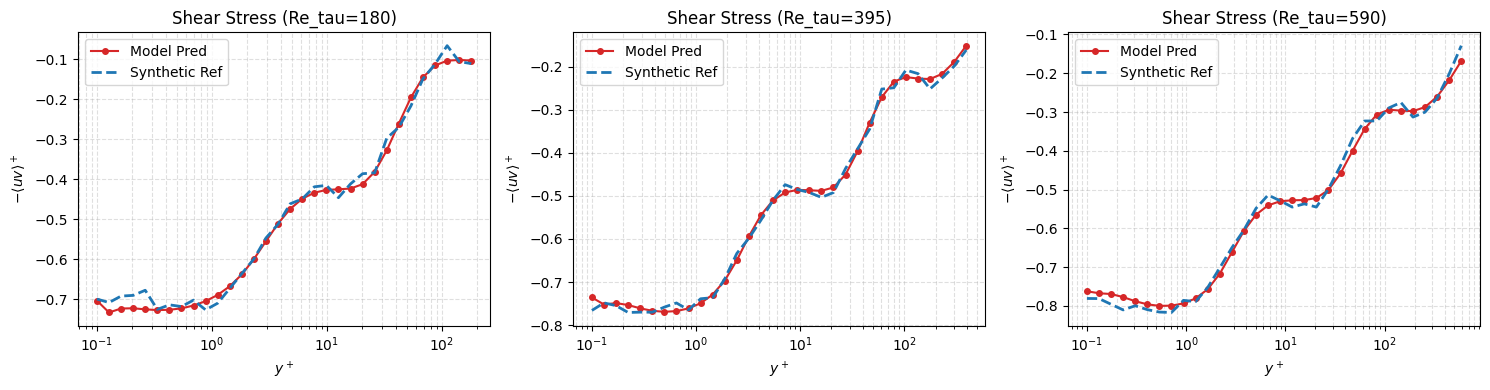

In [1]:
# ==========================================================
# FINAL MERGED COURSE CODE (DL/ML)
# Includes:
# 1) Synthetic turbulence-style dataset
# 2) Baselines + LSTM ablation grid
# 3) Leaderboard CSV export
# 4) Best-model training history
# 5) Best-model parity plot
# 6) Shear stress profile plots: -<uv>+ vs y+ (log scale)
# ==========================================================

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# --------------------------
# 1) Config
# --------------------------
CFG = {
    "seed": 42,
    "seq_len": 32,
    "n_samples": 3000,
    "batch_size": 64,
    "epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir": "results_dl_ml_final",
    # LSTM ablation search space
    "ablation_hidden_dims": [8, 16, 32],
    "ablation_num_layers": [1, 2, 3],
    # Re_tau values for shear profile plotting
    "profile_re_list": [180, 395, 590],
}


# --------------------------
# 2) Utilities
# --------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def regression_metrics(y_true, y_pred):
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    mse = float(np.mean((yt - yp) ** 2))
    mae = float(np.mean(np.abs(yt - yp)))
    var = float(np.var(yt))
    r2 = float(1.0 - mse / var) if var > 1e-12 else float("nan")
    return mse, mae, r2


def split_dataset(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
    n = len(X)
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    tr_end = int(train_ratio * n)
    va_end = int((train_ratio + val_ratio) * n)

    tr = idx[:tr_end]
    va = idx[tr_end:va_end]
    te = idx[va_end:]

    return X[tr], y[tr], X[va], y[va], X[te], y[te]


# --------------------------
# 3) Synthetic Dataset
# --------------------------
def make_features(re_tau, seq_len=32):
    y_plus = np.geomspace(0.1, re_tau, seq_len).astype(np.float32)
    re_n = np.clip((re_tau - 150.0) / (600.0 - 150.0), 0.0, 1.0)
    s11 = np.zeros(seq_len, dtype=np.float32)
    s12 = (1.0 / (1.0 + 0.05 * y_plus)).astype(np.float32)
    y_n = (y_plus / re_tau).astype(np.float32)
    x = np.stack([np.full(seq_len, re_n, dtype=np.float32), s11, s12, y_n], axis=1)
    return y_plus, x


def synthetic_target(y_plus, x, rng):
    y_n = x[:, 3]
    s12 = x[:, 2]
    re_n = x[0, 0]
    target = (
        0.28 * np.exp(-1.7 * y_n)
        + 0.18 * np.exp(-0.18 * y_plus)
        + 0.06 * np.sin(2.5 * np.log1p(y_plus))
        + 0.10 * re_n
        + 0.22 * s12
        + rng.normal(0.0, 0.015, len(y_plus))
    )
    return np.clip(target, 0.0, None).astype(np.float32)


def generate_synthetic_dataset(n_samples=3000, seq_len=32, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n_samples, seq_len, 4), dtype=np.float32)
    Y = np.zeros((n_samples, seq_len, 1), dtype=np.float32)

    for i in range(n_samples):
        re_tau = rng.uniform(150, 600)
        y_plus, x = make_features(re_tau, seq_len=seq_len)
        y = synthetic_target(y_plus, x, rng)
        X[i] = x
        Y[i, :, 0] = y

    return X, Y


# --------------------------
# 4) Models
# --------------------------
class LinearBaseline(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.fc(x)


class MLPBaseline(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)


class RANSLSTM(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out)


# --------------------------
# 5) Train / Eval
# --------------------------
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            pred = model(xb)
            loss = criterion(pred, yb)
            if is_train:
                loss.backward()
                optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / max(1, n)


@torch.no_grad()
def predict(model, loader, device="cpu"):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(pred)
    return np.concatenate(ys, axis=0), np.concatenate(ps, axis=0)


def train_and_evaluate(model, name, X, y, cfg):
    Xtr, Ytr, Xva, Yva, Xte, Yte = split_dataset(
        X, y, train_ratio=0.7, val_ratio=0.15, seed=cfg["seed"]
    )

    tr_loader = DataLoader(
        TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Ytr)),
        batch_size=cfg["batch_size"],
        shuffle=True,
    )
    va_loader = DataLoader(
        TensorDataset(torch.from_numpy(Xva), torch.from_numpy(Yva)),
        batch_size=cfg["batch_size"],
        shuffle=False,
    )
    te_loader = DataLoader(
        TensorDataset(torch.from_numpy(Xte), torch.from_numpy(Yte)),
        batch_size=cfg["batch_size"],
        shuffle=False,
    )

    model = model.to(cfg["device"])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    best_val = float("inf")
    best_state = None
    tr_hist, va_hist = [], []

    for _ in range(cfg["epochs"]):
        tr_loss = run_epoch(model, tr_loader, criterion, optimizer, cfg["device"])
        va_loss = run_epoch(model, va_loader, criterion, None, cfg["device"])
        scheduler.step(va_loss)

        tr_hist.append(tr_loss)
        va_hist.append(va_loss)

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    yv_true, yv_pred = predict(model, va_loader, cfg["device"])
    yt_true, yt_pred = predict(model, te_loader, cfg["device"])

    val_mse, val_mae, val_r2 = regression_metrics(yv_true, yv_pred)
    test_mse, test_mae, test_r2 = regression_metrics(yt_true, yt_pred)

    return {
        "name": name,
        "model": model,
        "train_loss": tr_hist,
        "val_loss": va_hist,
        "val_mse": val_mse,
        "val_mae": val_mae,
        "val_r2": val_r2,
        "test_mse": test_mse,
        "test_mae": test_mae,
        "test_r2": test_r2,
        "y_test_true": yt_true,
        "y_test_pred": yt_pred,
    }


# --------------------------
# 6) Plot helpers
# --------------------------
def plot_top5_bar(df, out_dir):
    top5 = df.head(5)
    plt.figure(figsize=(9, 4))
    plt.bar(top5["model"], top5["test_mse"])
    plt.xticks(rotation=25, ha="right")
    plt.title("Top-5 Models by Test MSE")
    plt.ylabel("Test MSE")
    plt.tight_layout()
    plt.savefig(out_dir / "top5_test_mse.png", dpi=150)
    plt.show()


def plot_best_history(best_res, out_dir):
    plt.figure(figsize=(7, 4))
    plt.plot(best_res["train_loss"], label="Train Loss")
    plt.plot(best_res["val_loss"], "--", label="Val Loss")
    plt.title(f"Best Model Training History: {best_res['name']}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "best_model_history.png", dpi=150)
    plt.show()


def plot_best_parity(best_res, seed, out_dir):
    yt = best_res["y_test_true"].reshape(-1)
    yp = best_res["y_test_pred"].reshape(-1)
    n_show = min(4000, len(yt))
    idx = np.random.default_rng(seed).choice(len(yt), size=n_show, replace=False)

    lo = float(min(yt.min(), yp.min()))
    hi = float(max(yt.max(), yp.max()))

    plt.figure(figsize=(5, 5))
    plt.scatter(yt[idx], yp[idx], s=8, alpha=0.35)
    plt.plot([lo, hi], [lo, hi], "r--", lw=1.2)
    plt.title(f"Parity Plot (Best: {best_res['name']})")
    plt.xlabel("True")
    plt.ylabel("Pred")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "best_model_parity.png", dpi=150)
    plt.show()


@torch.no_grad()
def plot_shear_profiles(best_res, cfg, out_dir):
    model = best_res["model"]
    model.eval()

    re_list = cfg["profile_re_list"]
    plt.figure(figsize=(15, 4))

    for i, re_tau in enumerate(re_list, 1):
        y_plus, x = make_features(re_tau, seq_len=cfg["seq_len"])
        xt = torch.from_numpy(x).unsqueeze(0).to(cfg["device"])
        pred = model(xt).squeeze().cpu().numpy()

        # Optional synthetic reference (expected profile) for visual context
        rng = np.random.default_rng(cfg["seed"] + i)
        ref = synthetic_target(y_plus, x, rng)

        plt.subplot(1, len(re_list), i)
        plt.plot(y_plus, -pred, "o-", color="#d62728", markersize=4, label="Model Pred")
        plt.plot(y_plus, -ref, "--", color="#1f77b4", linewidth=2, label="Synthetic Ref")
        plt.xscale("log")
        plt.title(f"Shear Stress (Re_tau={re_tau})")
        plt.xlabel(r"$y^+$")
        plt.ylabel(r"$-\langle uv \rangle^+$")
        plt.grid(True, which="both", ls="--", alpha=0.4)
        plt.legend()

    plt.tight_layout()
    plt.savefig(out_dir / "shear_stress_profiles.png", dpi=150)
    plt.show()


# --------------------------
# 7) Main
# --------------------------
def main():
    out_dir = Path(CFG["output_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    set_seed(CFG["seed"])
    print("Device:", CFG["device"])

    X, y = generate_synthetic_dataset(
        n_samples=CFG["n_samples"],
        seq_len=CFG["seq_len"],
        seed=CFG["seed"],
    )
    print("Dataset shape:", X.shape, y.shape)

    all_results = []

    # Baselines + default LSTM
    models = [
        ("Linear", LinearBaseline(input_dim=4)),
        ("MLP(h=32)", MLPBaseline(input_dim=4, hidden_dim=32)),
        ("LSTM(h=16,l=2)", RANSLSTM(input_dim=4, hidden_dim=16, num_layers=2, dropout=0.2)),
    ]

    for name, model in models:
        print(f"Running: {name}")
        all_results.append(train_and_evaluate(model, name, X, y, CFG))

    # LSTM ablation
    for h in CFG["ablation_hidden_dims"]:
        for l in CFG["ablation_num_layers"]:
            name = f"LSTM(h={h},l={l})"
            print(f"Running: {name}")
            model = RANSLSTM(input_dim=4, hidden_dim=h, num_layers=l, dropout=0.2)
            all_results.append(train_and_evaluate(model, name, X, y, CFG))

    # Leaderboard
    rows = []
    for r in all_results:
        rows.append({
            "model": r["name"],
            "val_mse": r["val_mse"],
            "val_mae": r["val_mae"],
            "val_r2": r["val_r2"],
            "test_mse": r["test_mse"],
            "test_mae": r["test_mae"],
            "test_r2": r["test_r2"],
            "best_val_loss": float(np.min(r["val_loss"])),
        })

    df = pd.DataFrame(rows).sort_values("test_mse", ascending=True).reset_index(drop=True)
    df.to_csv(out_dir / "leaderboard.csv", index=False)

    with open(out_dir / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(CFG, f, indent=2)

    print("\n=== Leaderboard (Top 10) ===")
    print(df.head(10).to_string(index=False))
    print(f"\nSaved outputs in: {out_dir.resolve()}")

    # Best model diagnostics
    best_name = df.iloc[0]["model"]
    best_res = next(r for r in all_results if r["name"] == best_name)

    plot_top5_bar(df, out_dir)
    plot_best_history(best_res, out_dir)
    plot_best_parity(best_res, CFG["seed"], out_dir)
    plot_shear_profiles(best_res, CFG, out_dir)


if __name__ == "__main__":
    main()